# Qwen2.5-VL-3B: Zero-Shot Object Localization, Action Recognition & Scene Understanding

## Research-Grade Vision-Language Evaluation

This notebook evaluates Qwen2.5-VL-3B-Instruct as a zero-shot multimodal perception model for:

1. Object localization
2. Observable action/state recognition
3. Scene-level understanding

The experiment additionally measures structured-output reliability, inference latency, GPU memory consumption, and repeatability.

**Important:** JSON validity is not detection accuracy. Quantitative localization and action-recognition accuracy require independent ground-truth annotations.

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes qwen-vl-utils huggingface_hub

In [ ]:
import gc
import json
import re
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from IPython.display import display
from huggingface_hub import hf_hub_download

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")

In [ ]:
CONFIG = {
    "model_id": "Qwen/Qwen2.5-VL-3B-Instruct",
    "dataset_repo": "WasiqSaleem/Portfolio_Assest",
    "dataset_repo_type": "dataset",
    "image_filename": "cat.jpg",
    "max_new_tokens": 512,
    "num_repeats": 3,
    "output_dir": "/content/qwen25vl_research_results",
}

OUTPUT_DIR = Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps(CONFIG, indent=2))

## 1. Experimental Input

The image is retrieved from the project's public Hugging Face dataset. No ground-truth annotations are supplied to the model during inference.

In [ ]:
cached_image = hf_hub_download(
    repo_id=CONFIG["dataset_repo"],
    filename=CONFIG["image_filename"],
    repo_type=CONFIG["dataset_repo_type"],
)

IMAGE_PATH = Path("/content") / CONFIG["image_filename"]

if not IMAGE_PATH.exists():
    import shutil
    shutil.copy2(cached_image, IMAGE_PATH)

image = Image.open(IMAGE_PATH).convert("RGB")

print("Image:", IMAGE_PATH)
print("Resolution:", image.width, "x", image.height)
display(image)

## 2. Fixed Research Prompt and Output Schema

The prompt is fixed before inference. Bounding boxes must use original-image pixel coordinates, and actions must describe observable evidence rather than unsupported intentions.

In [ ]:
SYSTEM_PROMPT = (
    "You are a vision-language perception model evaluated in a controlled research experiment.\n\n"
    "Tasks:\n"
    "1. Object localization\n"
    "2. Observable action/state recognition\n"
    "3. Global scene description\n\n"
    "Return ONLY valid JSON. No Markdown or explanatory text.\n\n"
    "Required schema:\n"
    "{\n"
    '  "objects": [{"bbox_2d": [x1,y1,x2,y2], "label": "object", "action": "observable action or state"}],\n'
    '  "scene_description": "concise scene description"\n'
    "}\n\n"
    f"Original image size: {image.width} x {image.height} pixels.\n"
    "Rules:\n"
    "1. bbox_2d contains four integer pixel coordinates.\n"
    "2. Coordinates refer to the original image.\n"
    "3. Require 0 <= x1 < x2 <= image width and 0 <= y1 < y2 <= image height.\n"
    "4. Include only visually supported objects.\n"
    "5. Do not invent hidden objects.\n"
    "6. Describe observable actions/states only.\n"
    '7. If action cannot be determined reliably, use "unknown".\n'
    "8. Keep labels short and concrete.\n"
    "9. Keep scene_description below 40 words.\n"
    "10. If no object can be confidently localized, return an empty objects list.\n"
    "11. Return valid JSON and nothing outside it."
)

USER_PROMPT = (
    "Analyze this RGB image. Identify visible objects, estimate their 2D bounding boxes, "
    "describe their observable action/state, and summarize the overall scene. "
    "Do not infer information that is not visually supported."
)

## 3. Load Qwen2.5-VL-3B

NF4 4-bit quantization is used to make the 3B model practical on constrained GPU hardware. Quantization is explicitly recorded as part of the experimental condition.

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_storage=torch.float16,
)

print("Loading:", CONFIG["model_id"])

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    CONFIG["model_id"],
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype="auto",
    attn_implementation="sdpa",
)

processor = AutoProcessor.from_pretrained(CONFIG["model_id"])
model.eval()

print("Model loaded successfully.")

## 4. Robust JSON Parsing and Validation

The raw generation is preserved. The parser attempts to recover JSON while the validator checks the schema and bounding-box coordinates.

In [ ]:
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def parse_json_output(raw_text):
    if not raw_text:
        return None, "empty_output"

    text = raw_text.strip()

    # Remove markdown fences
    text = re.sub(
        r"^\s*```(?:json)?\s*",
        "",
        text,
        flags=re.IGNORECASE
    )
    text = re.sub(
        r"\s*```\s*$",
        "",
        text,
        flags=re.IGNORECASE
    )

    # Attempt direct JSON parsing
    try:
        return json.loads(text), "direct_json"
    except json.JSONDecodeError:
        pass

    # Try to locate the outermost JSON object
    start = text.find("{")
    end = text.rfind("}")

    if start != -1 and end > start:
        candidate = text[start:end + 1]

        try:
            return json.loads(candidate), "extracted_json"
        except json.JSONDecodeError:
            pass

    return None, "invalid_json"

def validate_prediction(prediction, width, height):
    errors = []

    if not isinstance(prediction, dict):
        return False, ["root_not_object"]

    if "objects" not in prediction:
        errors.append("missing_objects")

    if "scene_description" not in prediction:
        errors.append("missing_scene_description")

    objects = prediction.get("objects", [])

    if not isinstance(objects, list):
        errors.append("objects_not_list")
        objects = []

    for i, obj in enumerate(objects):
        if not isinstance(obj, dict):
            errors.append(f"object_{i}_not_object")
            continue

        bbox = obj.get("bbox_2d")

        if not isinstance(bbox, list) or len(bbox) != 4:
            errors.append(f"object_{i}_invalid_bbox")
            continue

        if not all(isinstance(v, (int, float)) for v in bbox):
            errors.append(f"object_{i}_bbox_non_numeric")
            continue

        x1, y1, x2, y2 = bbox

        if not (0 <= x1 < x2 <= width):
            errors.append(f"object_{i}_invalid_x_coordinates")

        if not (0 <= y1 < y2 <= height):
            errors.append(f"object_{i}_invalid_y_coordinates")

        if not obj.get("label"):
            errors.append(f"object_{i}_missing_label")

        if not obj.get("action"):
            errors.append(f"object_{i}_missing_action")

    return len(errors) == 0, errors

## 5. Zero-Shot Inference

Only the RGB image and fixed research prompt are provided. No ground-truth labels, bounding boxes, or action annotations are supplied.

In [ ]:
def run_inference(image, seed=42):
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.cuda.reset_peak_memory_stats()

    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": USER_PROMPT},
            ],
        },
    ]

    text_prompt = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    kwargs = {
        "text": [text_prompt],
        "images": image_inputs,
        "return_tensors": "pt",
        "padding": True,
    }

    if video_inputs is not None:
        kwargs["videos"] = video_inputs

    inputs = processor(**kwargs)

    model_device = next(model.parameters()).device

    inputs = {
        k: v.to(model_device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

    start = time.perf_counter()

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=CONFIG["max_new_tokens"],
            do_sample=False,
        )

    elapsed = time.perf_counter() - start

    generated_text = processor.batch_decode(
        generated_ids[:, inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    )[0].strip()

    peak_vram_gb = (
        torch.cuda.max_memory_allocated() / 1e9
        if torch.cuda.is_available()
        else np.nan
    )

    parsed, parse_method = parse_json_output(generated_text)

    if parsed is not None:
        valid, validation_errors = validate_prediction(
            parsed, image.width, image.height
        )
    else:
        valid, validation_errors = False, ["json_parse_failed"]

    return {
        "raw_output": generated_text,
        "parsed_output": parsed,
        "parse_method": parse_method,
        "schema_valid": valid,
        "validation_errors": validation_errors,
        "inference_time_s": elapsed,
        "peak_vram_gb": peak_vram_gb,
    }


result = run_inference(image, seed=SEED)

print("=" * 80)
print("RAW MODEL OUTPUT")
print("=" * 80)
print(result["raw_output"])

print("\nJSON parsing:", result["parse_method"])
print("Schema valid:", result["schema_valid"])
print("Inference time:", f'{result["inference_time_s"]:.3f} s')
print("Peak VRAM:", f'{result["peak_vram_gb"]:.2f} GB')
print("Validation errors:", result["validation_errors"])

## 6. Structured Prediction

In [ ]:
print(json.dumps(result["parsed_output"], indent=2, ensure_ascii=False))

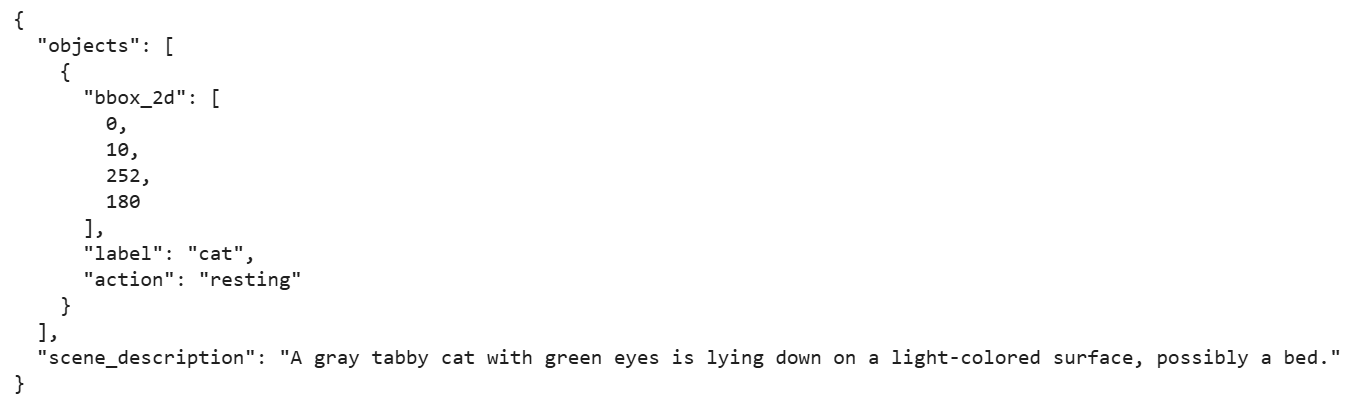

## 7. Bounding-Box and Action Visualization

This is a qualitative localization inspection. It is not a quantitative accuracy measurement without ground-truth boxes.

In [ ]:
def visualize_predictions(image, prediction):
    canvas = image.copy()
    draw = ImageDraw.Draw(canvas)

    if prediction is None:
        display(canvas)
        return

    for idx, obj in enumerate(prediction.get("objects", []), start=1):
        bbox = obj.get("bbox_2d")

        if not bbox or len(bbox) != 4:
            continue

        x1, y1, x2, y2 = map(int, bbox)
        label = obj.get("label", "object")
        action = obj.get("action", "unknown")

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text(
            (x1, max(0, y1 - 18)),
            f"{idx}: {label} | {action}",
            fill="red",
        )

    plt.figure(figsize=(12, 8))
    plt.imshow(canvas)
    plt.title("Qwen2.5-VL Zero-Shot Perception")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


visualize_predictions(image, result["parsed_output"])

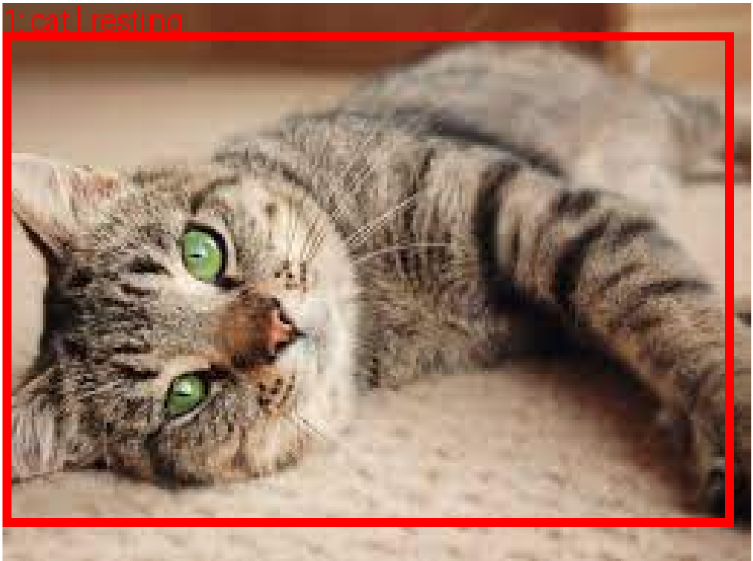

## 8. Repeatability and Computational Performance

The same image is evaluated repeatedly using deterministic decoding.

Repeatability measures output stability, not correctness.

In [ ]:
records = []

for run_id in range(1, CONFIG["num_repeats"] + 1):
    r = run_inference(image, seed=SEED)
    prediction = r["parsed_output"]

    if isinstance(prediction, dict):
        n_objects = len(prediction.get("objects", []))
        scene = prediction.get("scene_description", "")
    else:
        n_objects = 0
        scene = ""

    records.append({
        "run": run_id,
        "json_valid": r["schema_valid"],
        "num_objects": n_objects,
        "latency_s": r["inference_time_s"],
        "peak_vram_gb": r["peak_vram_gb"],
        "scene_description": scene,
        "raw_output": r["raw_output"],
    })

repeat_df = pd.DataFrame(records)

display(
    repeat_df[
        [
            "run",
            "json_valid",
            "num_objects",
            "latency_s",
            "peak_vram_gb",
            "scene_description",
        ]
    ]
)

In [ ]:
summary_df = pd.DataFrame([{
    "Model": CONFIG["model_id"],
    "Quantization": "NF4 4-bit",
    "Runs": len(repeat_df),
    "JSON Valid Rate": repeat_df["json_valid"].mean(),
    "Mean Latency (s)": repeat_df["latency_s"].mean(),
    "Latency Std (s)": repeat_df["latency_s"].std(ddof=1) if len(repeat_df) > 1 else 0.0,
    "Mean Peak VRAM (GB)": repeat_df["peak_vram_gb"].mean() if torch.cuda.is_available() else np.nan,
    "Mean Objects": repeat_df["num_objects"].mean(),
}])

display(summary_df)

## 9. Research-Level Evaluation Framework

### Directly measurable without annotations

- JSON validity rate
- schema validity rate
- inference latency
- latency variability
- peak GPU memory
- number of predicted objects
- qualitative localization
- scene-description consistency
- repeatability

### Metrics requiring independent ground truth

For a proper quantitative benchmark, annotate object classes, bounding boxes, observable actions/states, and scene-level labels.

Then calculate:

- IoU
- precision / recall / F1
- mAP
- action macro-F1
- scene classification accuracy
- localization error
- repeatability / consistency

A valid JSON response must not be reported as evidence of detection accuracy.

In [ ]:
research_record = {
    "experiment": "Qwen2.5-VL-3B zero-shot single-image perception",
    "model": CONFIG["model_id"],
    "quantization": "NF4 4-bit",
    "seed": SEED,
    "image": {
        "filename": CONFIG["image_filename"],
        "width": image.width,
        "height": image.height,
    },
    "protocol": {
        "max_new_tokens": CONFIG["max_new_tokens"],
        "deterministic_decoding": True,
        "num_repeats": CONFIG["num_repeats"],
    },
    "single_run": result,
    "repeat_runs": records,
    "summary": summary_df.to_dict(orient="records"),
}

record_path = OUTPUT_DIR / "qwen25vl_experiment_record.json"

with open(record_path, "w", encoding="utf-8") as f:
    json.dump(research_record, f, indent=2, ensure_ascii=False, default=str)

print("Research record saved to:", record_path)

# Interpretation and Limitations

The Qwen2.5-VL-3B experiment demonstrates zero-shot visual perception, including object localization, observable action/state recognition, and scene understanding. In the example, the model correctly identifies a cat, describes it as resting, and provides a bounding box and scene description.

The structured output also demonstrates that the model can produce machine-readable JSON, which is useful for downstream applications. However, JSON validity only measures output format and does not prove perception accuracy.

**Limitations: **The experiment uses a single image, so the results cannot be generalized to broader visual perception performance. No ground-truth bounding boxes or action labels are provided, meaning quantitative metrics such as IoU, mAP, precision, recall, or F1 cannot be calculated. The experiment also uses NF4 4-bit quantization, which may affect model behavior and performance.

Overall, the experiment demonstrates successful zero-shot multimodal perception and structured output generation, but a larger annotated dataset is required to quantitatively evaluate localization, action recognition, and scene-understanding accuracy.

# Conclusion

The final workflow is:

**RGB image → Qwen2.5-VL multimodal reasoning → object localization → action/state recognition → scene description → structured JSON → validation → visualization → repeatability → computational profiling**

The methodology deliberately separates:

**output validity ≠ perception accuracy ≠ repeatability ≠ computational efficiency**

For a larger research study, this notebook can be extended to a multi-image annotated benchmark while keeping the same prompt, schema, hardware, decoding settings, and evaluation protocol.